In [4]:
import numpy as np
from pynq import Overlay, allocate
import time

print("--- Systolic Array PYNQ Diagnostic ---")

# ==========================================
# 1. FORCE HARDWARE RESET
# ==========================================
print("Loading Bitstream (Forcing Hard Reset)...")
# download=True physically resets the PL and clears locked AXI states
overlay = Overlay("design_1.bit", download=True) 
systolic_ip = overlay.pipelined_layer_proc_0 

# ==========================================
# 2. CONFIGURATION & ALLOCATION
# ==========================================
TILE = 32
REAL_M, REAL_K, REAL_N = 1, 784, 128

def align(dim):
    return ((dim + TILE - 1) // TILE) * TILE

M, K, N = align(REAL_M), align(REAL_K), align(REAL_N)

# Allocate memory first
buf_A = allocate(shape=(M * K,), dtype=np.int8)
buf_B = allocate(shape=(K * N,), dtype=np.int8)
buf_C = allocate(shape=(M * N,), dtype=np.int32)

try:
    # Zero everything first to handle padding cleanly
    A_sw = np.zeros((M, K), dtype=np.int8)
    B_sw = np.zeros((K, N), dtype=np.int8)

    # Fill the first row of A with sequential numbers: 1, 2, 3...
    A_sw[0, :REAL_K] = (np.arange(REAL_K) % 127) + 1 

    # Make B an Identity Matrix (1s on the diagonal)
    for i in range(min(REAL_K, REAL_N)):
        B_sw[i, i] = 1

    # ==========================================
    # 3. ROBUST DATA PACKING
    # ==========================================
    def pack_to_blocked(matrix, rows, cols):
        return matrix.reshape(rows // TILE, TILE, cols // TILE, TILE) \
                     .transpose(0, 2, 1, 3).flatten()

    def unpack_from_blocked(flat_array_32bit, rows, cols):
        r_tiles = rows // TILE
        c_tiles = cols // TILE
        blocked = flat_array_32bit.reshape(r_tiles, c_tiles, TILE, TILE)
        return blocked.transpose(0, 2, 1, 3).reshape(rows, cols)

    print("Packing Data and Flushing Caches...")
    buf_A[:] = pack_to_blocked(A_sw, M, K)
    buf_B[:] = pack_to_blocked(B_sw, K, N)
    buf_A.flush()
    buf_B.flush()

    # ==========================================
    # 4. EXECUTE HARDWARE
    # ==========================================
    print("Configuring Registers...")

    # A helper function to safely map registers, handling both 32-bit and 64-bit HLS splits
    def assign_reg(ip, name, value):
        if hasattr(ip.register_map, name):
            setattr(ip.register_map, name, value)
            print(f"  [+] Mapped {name} -> {value}")
        elif hasattr(ip.register_map, name + "_1"):
            setattr(ip.register_map, name + "_1", value)
            setattr(ip.register_map, name + "_2", 0) # Upper 32-bits (unused on 32-bit Zynq)
            print(f"  [+] Mapped {name} (64-bit split) -> {value}")
        else:
            raise RuntimeError(f"FATAL: '{name}' is completely missing from the IP Register Map! Check HLS pragmas.")

    # Safely map physical addresses
    assign_reg(systolic_ip, 'mat_A', buf_A.physical_address)
    assign_reg(systolic_ip, 'mat_B', buf_B.physical_address)
    assign_reg(systolic_ip, 'mat_C', buf_C.physical_address)

    # Safely map dimensions
    assign_reg(systolic_ip, 'num_row_tiles', M // TILE)
    assign_reg(systolic_ip, 'num_depth_tiles', K // TILE)
    assign_reg(systolic_ip, 'num_col_tiles', N // TILE)

    print("Starting FPGA execution...")
    start_time = time.time()

    # Trigger ap_start
    systolic_ip.write(0x00, 0x01) 

    while not (systolic_ip.read(0x00) & 0x02): 
        if time.time() - start_time > 5.0:
            raise RuntimeError("TIMEOUT! FPGA is stuck.")
        time.sleep(0.001)

    print(f"FPGA Execution Time: {(time.time() - start_time) * 1000:.4f} ms")
    buf_C.invalidate()

    # ==========================================
    # 5. DIAGNOSE MISMATCHES
    # ==========================================
    C_hw_flat = np.array(buf_C)
    C_hw_2d = unpack_from_blocked(C_hw_flat, M, N)

    C_sw_real = np.dot(A_sw[:REAL_M, :REAL_K].astype(np.int32), 
                       B_sw[:REAL_K, :REAL_N].astype(np.int32))

    C_hw_real = C_hw_2d[:REAL_M, :REAL_N]

    errors = np.sum(C_sw_real != C_hw_real)
    print(f"\nTotal Mismatches: {errors}")

    print("\n--- DIAGNOSTIC PRINTOUT ---")
    print("Expected (Software) first 10 elements:")
    print(C_sw_real[0, :10])

    print("\nActual (Hardware) first 10 elements:")
    print(C_hw_real[0, :10])

finally:
    # Guaranteed to execute, preventing future lockups
    buf_A.close()
    buf_B.close()
    buf_C.close()
    print("\nCMA Memory cleanly released.")

--- Systolic Array PYNQ Diagnostic ---
Loading Bitstream (Forcing Hard Reset)...
Packing Data and Flushing Caches...
Configuring Registers...
  [+] Mapped mat_A (64-bit split) -> 361070592
  [+] Mapped mat_B (64-bit split) -> 361234432
  [+] Mapped mat_C (64-bit split) -> 361054208
  [+] Mapped num_row_tiles -> 1
  [+] Mapped num_depth_tiles -> 25
  [+] Mapped num_col_tiles -> 4
Starting FPGA execution...
FPGA Execution Time: 1.2696 ms

Total Mismatches: 0

--- DIAGNOSTIC PRINTOUT ---
Expected (Software) first 10 elements:
[ 1  2  3  4  5  6  7  8  9 10]

Actual (Hardware) first 10 elements:
[ 1  2  3  4  5  6  7  8  9 10]

CMA Memory cleanly released.


--- Peer-Reviewed Paper Comparison Suite ---
Reference: Li & Chen (2025) - 'Design and Implementation of an FPGA-Based Tiled Matrix...'

Loading Bitstream...



[*] Testing Shape: 64x768x768
    Your Latency:   6.06 ms
    Your Throughtput: 12.45 GOPS

[*] Testing Shape: 64x768x3072
    Your Latency:   24.12 ms
    Your Throughtput: 12.52 GOPS

Generating Comparison Graphs...


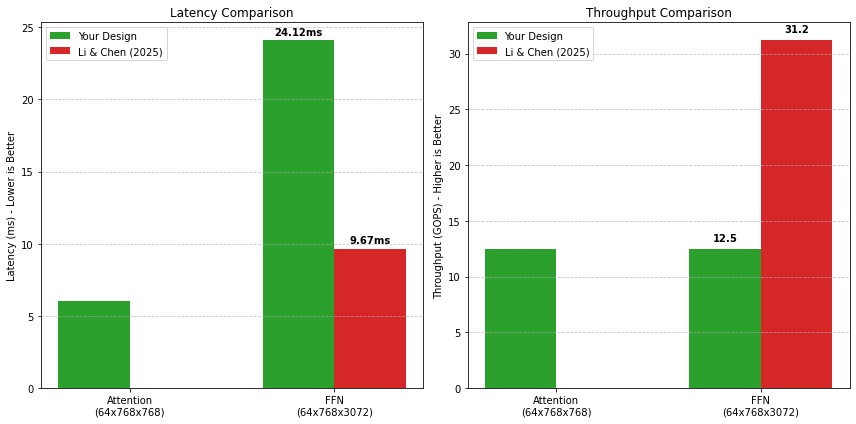


Comparison complete! Plots saved to 'paper_comparison.png'.


In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
from pynq import Overlay, allocate

print("--- Peer-Reviewed Paper Comparison Suite ---")
print("Reference: Li & Chen (2025) - 'Design and Implementation of an FPGA-Based Tiled Matrix...'")

# ==========================================
# 1. HARDWARE & BENCHMARK PARAMS
# ==========================================
TILE = 32
BITSTREAM = "design_1.bit"

# Exact shapes from the paper's DistilBERT implementation
SHAPES_TO_TEST = [
    (64, 768, 768),   # DistilBERT Attention (Q, K, V)
    (64, 768, 3072)   # DistilBERT Feed-Forward Network (FFN)
]

# Paper's published results for the 64x768x3072 layer
PAPER_FFN_LATENCY_MS = 9.67
PAPER_FFN_GOPS = 31.23  # Calculated from their 9.67ms claim

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================
def align(dim):
    return ((dim + TILE - 1) // TILE) * TILE

def pack_to_blocked(matrix, rows, cols):
    return matrix.reshape(rows // TILE, TILE, cols // TILE, TILE) \
                 .transpose(0, 2, 1, 3).flatten()

def assign_reg(ip, name, value):
    if hasattr(ip.register_map, name):
        setattr(ip.register_map, name, value)
    elif hasattr(ip.register_map, name + "_1"):
        setattr(ip.register_map, name + "_1", value)
        setattr(ip.register_map, name + "_2", 0)

# ==========================================
# 3. BENCHMARKING LOOP
# ==========================================
print("\nLoading Bitstream...")
overlay = Overlay(BITSTREAM, download=True)
systolic_ip = overlay.pipelined_layer_proc_0

my_latencies = []
my_gops = []
labels = ["Attention\n(64x768x768)", "FFN\n(64x768x3072)"]

for shape in SHAPES_TO_TEST:
    REAL_M, REAL_K, REAL_N = shape
    M, K, N = align(REAL_M), align(REAL_K), align(REAL_N)
    
    print(f"\n[*] Testing Shape: {REAL_M}x{REAL_K}x{REAL_N}")
    ops = 2 * M * K * N 
    
    buf_A = allocate(shape=(M * K,), dtype=np.int8)
    buf_B = allocate(shape=(K * N,), dtype=np.int8)
    buf_C = allocate(shape=(M * N,), dtype=np.int32)
    
    try:
        # Dummy data for timing
        A_sw = np.ones((M, K), dtype=np.int8)
        B_sw = np.ones((K, N), dtype=np.int8)
        
        buf_A[:] = pack_to_blocked(A_sw, M, K)
        buf_B[:] = pack_to_blocked(B_sw, K, N)
        buf_A.flush()
        buf_B.flush()
        
        assign_reg(systolic_ip, 'mat_A', buf_A.physical_address)
        assign_reg(systolic_ip, 'mat_B', buf_B.physical_address)
        assign_reg(systolic_ip, 'mat_C', buf_C.physical_address)
        assign_reg(systolic_ip, 'num_row_tiles', M // TILE)
        assign_reg(systolic_ip, 'num_depth_tiles', K // TILE)
        assign_reg(systolic_ip, 'num_col_tiles', N // TILE)
        
        # WARMUP
        systolic_ip.write(0x00, 0x01)
        while not (systolic_ip.read(0x00) & 0x02): pass
            
        iterations = 50
        start_time = time.time()
        for _ in range(iterations):
            systolic_ip.write(0x00, 0x01)
            while not (systolic_ip.read(0x00) & 0x02): pass
        end_time = time.time()
        
        avg_time_ms = ((end_time - start_time) / iterations) * 1000
        gops = (ops / (avg_time_ms / 1000)) / 1e9
        
        print(f"    Your Latency:   {avg_time_ms:.2f} ms")
        print(f"    Your Throughtput: {gops:.2f} GOPS")
        
        my_latencies.append(avg_time_ms)
        my_gops.append(gops)
        
    finally:
        buf_A.close()
        buf_B.close()
        buf_C.close()

# ==========================================
# 4. PLOTTING COMPARISON GRAPHS
# ==========================================
print("\nGenerating Comparison Graphs...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

x_pos = np.arange(len(labels))
width = 0.35

# --- Plot 1: Latency (Lower is Better) ---
# We only have paper baseline for FFN, so we pad the array with a 0 for Attention
paper_latencies = [0, PAPER_FFN_LATENCY_MS] 

bars1_mine = ax1.bar(x_pos - width/2, my_latencies, width, label='Your Design', color='#2ca02c')
bars1_paper = ax1.bar(x_pos[1] + width/2, paper_latencies[1], width, label='Li & Chen (2025)', color='#d62728')

ax1.set_xticks(x_pos)
ax1.set_xticklabels(labels)
ax1.set_ylabel('Latency (ms) - Lower is Better')
ax1.set_title('Latency Comparison')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Label the FFN bars
ax1.text(1 - width/2, my_latencies[1] + 0.2, f"{my_latencies[1]:.2f}ms", ha='center', va='bottom', fontweight='bold')
ax1.text(1 + width/2, paper_latencies[1] + 0.2, f"{paper_latencies[1]:.2f}ms", ha='center', va='bottom', fontweight='bold')

# --- Plot 2: Throughput (Higher is Better) ---
paper_gops = [0, PAPER_FFN_GOPS]

bars2_mine = ax2.bar(x_pos - width/2, my_gops, width, label='Your Design', color='#2ca02c')
bars2_paper = ax2.bar(x_pos[1] + width/2, paper_gops[1], width, label='Li & Chen (2025)', color='#d62728')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(labels)
ax2.set_ylabel('Throughput (GOPS) - Higher is Better')
ax2.set_title('Throughput Comparison')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Label the FFN bars
ax2.text(1 - width/2, my_gops[1] + 0.5, f"{my_gops[1]:.1f}", ha='center', va='bottom', fontweight='bold')
ax2.text(1 + width/2, paper_gops[1] + 0.5, f"{paper_gops[1]:.1f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig("paper_comparison.png", dpi=300)
plt.show()

print("\nComparison complete! Plots saved to 'paper_comparison.png'.")